# ⚖️ Gatekeeper CTF Challenge — Level 5: The Weight of Truth

## The Story So Far

The reformed thief — now a respected data engineer at the bank — has proven himself time and again. After fixing the broken Sentinel in Level 4, the bank's leadership noticed his rare talent for understanding systems from the inside out.

One evening, the Chief Data Officer called him into a private meeting room.

*"We have a situation,"* she said, sliding a folder across the table. *"Our core prediction engine — the one that drives all downstream decisions — was built by a mathematician who left the company years ago. He didn't document anything. No saved model, no training logs, no notes. All we have is the data he used."*

She paused.

*"But here's the thing. We know the model was a perfect linear system. Zero residual error. Every prediction matched the output exactly. But we have no record of the model itself."*

She leaned forward.

*"I need you to recover that model. Look at the data. Use whatever tools, techniques, or methods you want — code, math, ML libraries, brute force, anything. Just rebuild the exact model that produces a perfect fit."*

---

## 🎯 Your Mission

The original model is a **linear regression** — it takes in input features and produces an output.

Your task is to **rebuild the exact model** that was originally used.

### 📌 Key Facts
- The dataset contains **input features** and a **target output** (`y`)
- The original model achieved **absolute 0 residual error** and an **R² score of exactly 1.0** — a mathematically perfect fit
- There is an **exact, unique model** that perfectly maps inputs to outputs
- You may use **any method** you want — coding, ML libraries, visualisation, trial and error — whatever works

### 🔑 Submission
Once you have your model, submit it using the **submission cell** at the bottom of this notebook.

The evaluation server will run your model against the original dataset. The flag is revealed **only** if:
- **R² = 1.0** 
- **Residual error = 0**

---

## 📦 Step 1: Load and Explore the Dataset

Start by loading the dataset and understanding its structure. Look at the features and the target variable.

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\n--- First 10 rows ---")
df.head(10)

: 

In [ ]:
import requests

# ── Configuration ─────────────────────────────────────────────────────────────
BASE_URL = ""
USERNAME = ""   # ← enter your CTF username
PASSWORD = ""   # ← enter your CTF password

# ── Login ─────────────────────────────────────────────────────────────────────
session = requests.Session()
resp = session.post(f"{BASE_URL}/api/notebook-login/", data={"username": USERNAME, "password": PASSWORD})
result = resp.json()

if result.get("success"):
    print(f"✅ Logged in as: {USERNAME}")
else:
    print(f"❌ Login failed: {result.get('message', 'Unknown error')}")

In [2]:
# Basic statistics
df.describe()

,X1,X2,y
count,15.000000,15.000000,15.000000
mean,1.600000,0.133333,3.333333
std,8.483598,7.799878,16.011900
min,-14.000000,-13.000000,-22.000000
25%,-3.000000,-5.500000,-7.000000
50%,1.000000,0.000000,1.000000
75%,8.000000,6.000000,17.500000
max,15.000000,14.000000,29.000000


## 🔍 Step 2: Analyse the Data

Study the relationships between the input features and the target variable. Use any technique — correlations, scatter plots, pattern recognition, or anything else that helps you understand how `y` is derived from `X1` and `X2`.

Correlations:
          X1        X2         y
X1  1.000000 -0.348879  0.889712
X2 -0.348879  1.000000  0.117436
y   0.889712  0.117436  1.000000


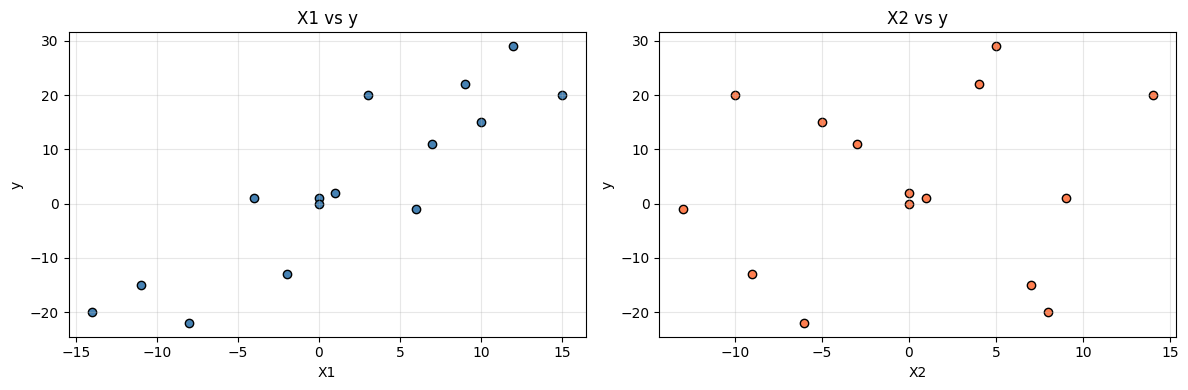

In [6]:
# Explore the data — use any approach you like
# Some ideas: correlations, scatter plots, checking special rows, etc.

# Correlation matrix
print("Correlations:")
print(df.corr())

# Scatter plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['X1'], df['y'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('X1'); axes[0].set_ylabel('y'); axes[0].set_title('X1 vs y')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['X2'], df['y'], color='coral', edgecolor='black')
axes[1].set_xlabel('X2'); axes[1].set_ylabel('y'); axes[1].set_title('X2 vs y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🧩 Step 3: Build Your Model

Use whatever method or technique you prefer to reconstruct the original model. Write your solution below.

In [ ]:
# ============================================================
# YOUR SOLUTION HERE
# ============================================================
# Build a model that perfectly fits the data.
# Use any method you want — sklearn, numpy, manual math, etc.
#
# Your model must achieve:
#   - R² = 1.0 
#   - Residual error = 0 
#
# The model must have a .predict() method that accepts
# a DataFrame with columns ['X1', 'X2'] and returns predictions.

# --- Write your solution below ---
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

## ✅ Step 4: Verify Your Model

If your model is correct, it should produce **zero residual error** across every row and an **R² score of 1.0**.

Run the verification cell below to check.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

if model is None:
    print("❌ You haven't built your model yet! Go back to Step 3.")
else:
    # Predict using your model
    y_pred = model.predict(df[['X1', 'X2']])
    
    # Calculate residuals
    residuals = df['y'].values - y_pred
    
    # Metrics
    r2 = r2_score(df['y'], y_pred)
    mse = mean_squared_error(df['y'], y_pred)
    
    print("=" * 50)
    print("        MODEL VERIFICATION REPORT")
    print("=" * 50)
    print(f"  R² Score        : {r2}")
    print(f"  MSE (residual)  : {mse}")
    print(f"  Max |residual|  : {max(abs(residuals))}")
    print("=" * 50)
    
    # Show model weights if available
    if hasattr(model, 'coef_'):
        print(f"\n  Coefficients    : {model.coef_}")
    if hasattr(model, 'intercept_'):
        print(f"  Intercept       : {model.intercept_}")
    
    if r2 == 1.0 and mse == 0.0:
        print("\n🎉 PERFECT FIT! Your model matches the original exactly!")
        print("   Proceed to Step 5 to submit your model.")
    else:
        print("\n❌ Not a perfect fit. Keep working on your model.")
        print("\nResiduals per row:")
        result_df = df[['X1', 'X2', 'y']].copy()
        result_df['y_pred'] = y_pred
        result_df['residual'] = residuals
        print(result_df)

## 📊 Optional: Visualise the Fit

Plot the predicted values against the actual values. A perfect model will show all points lying exactly on the diagonal line $y = x$.

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(df['y'], df['y_pred'], color='steelblue', edgecolor='black', s=80, zorder=5)
min_val = min(df['y'].min(), df['y_pred'].min()) - 2
max_val = max(df['y'].max(), df['y_pred'].max()) + 2
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit (y=x)')
axes[0].set_xlabel('Actual y', fontsize=12)
axes[0].set_ylabel('Predicted y', fontsize=12)
axes[0].set_title('Actual vs Predicted', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
axes[1].bar(range(len(df)), df['residual'], color='coral', edgecolor='black')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Data Point Index', fontsize=12)
axes[1].set_ylabel('Residual (y - y_pred)', fontsize=12)
axes[1].set_title('Residuals', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 📤 Step 5: Submit Your Model

Run the cell below to save your model as a `.pkl` file and submit it to the evaluation server.

The server will load your model, run it on the original dataset, and check the results.

**The flag is revealed only if R² = 1.0 (absolute) and residual error = 0 (absolute).**

In [ ]:
import joblib
import os

# ============================================================
# SUBMISSION — saves your model and uploads it to the server
# ============================================================

EVAL_URL   = f"{BASE_URL}/evaluate/challenge-5"
MODEL_PATH = "model.pkl"

if model is None:
    print("❌ You haven't built your model yet! Go back to Step 3.")
else:
    # Save the model to a .pkl file
    joblib.dump(model, MODEL_PATH)
    print(f"✅ Model saved to {MODEL_PATH}")

    print("\n" + "=" * 50)
    print("   SUBMITTING MODEL TO EVALUATION SERVER")
    print("=" * 50)

    try:
        with open(MODEL_PATH, "rb") as f:
            response = session.post(
                EVAL_URL,
                files={"file": ("model.pkl", f, "application/octet-stream")},
                timeout=30
            )
        result = response.json()

        print(f"\n📊 Result: {result['result'].upper()}")
        print(f"   {result['message']}")

        if result.get('r2_score') is not None:
            print(f"\n   R² Score       : {result['r2_score']}")
        if result.get('max_abs_error') is not None:
            print(f"   Max |Error|    : {result['max_abs_error']}")
        if result.get('mse') is not None:
            print(f"   MSE            : {result['mse']}")
        if result.get('coefficients') is not None:
            print(f"   Coefficients   : {result['coefficients']}")
        if result.get('intercept') is not None:
            print(f"   Intercept      : {result['intercept']}")

        if result.get('flag'):
            print(f"\n🏴 FLAG: {result['flag']}")

    except requests.exceptions.ConnectionError:
        print(f"\n❌ Could not connect to the evaluation server at {EVAL_URL}")
        print("   Make sure the server is running.")
    except Exception as e:
        print(f"\n❌ Error: {e}")